# Point Mass

## Setup

In [16]:
import sympy as sp
from sympy.physics.mechanics import *
import matplotlib.pyplot as plt

init_vprinting()

In [17]:
# Symbols
theta = dynamicsymbols('theta')
t = sp.symbols('t')

# Parameters
m, g, l = sp.symbols('m g l')

## Absolute Coordinates

In [18]:
# Define Frames
N = ReferenceFrame('N')

In [19]:
# Define Geometry
O = Point('O')
O.set_vel(N, 0)

P = O.locatenew('P', l * sp.sin(theta) * N.x - l * sp.cos(theta) * N.y)

In [20]:
# Compute Kinetic Energy
T = m * P.vel(N).dot(P.vel(N)) * 1/2

# Compute Potential Energy (assuming N.y is 'up')
V = m * g * P.pos_from(O).dot(N.y)

# Compute Lagrangian
L = T - V

Position Vector:


Velocity Vector:


Equation of Motion:


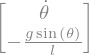

In [21]:
# Equations of Motion
LE = LagrangesMethod(L, [theta])
eom_abs = LE.form_lagranges_equations()
print("Position Vector:")
display(P.pos_from(O))
print("Velocity Vector:")
display(P.vel(N))
print("Equation of Motion:")
# display(sp.simplify(eom_abs))

display(sp.simplify(LE.rhs()))

## Relative Coordinates

In [22]:
# Define Frames
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta, N.z])
A.set_ang_vel(N, theta.diff() * N.z)

In [23]:
# Define Geometry
O = Point('O')
P = O.locatenew('P', l * A.y)

In [24]:
# Define Velocities
O.set_vel(N, 0) # O has 0 velocity in the reference frame
P.v2pt_theory(O, N, A); # P has velocity in N, calc as O and P are fixed in A

In [25]:
# Define Point Masses
P1 = Particle('P1', P, m)

In [26]:
# Retrieve Kinetic Energy
T = P1.kinetic_energy(N)

# Define Potential Energy
V = m * g * P.pos_from(O).dot(N.y)

# Compute Lagrangian
L = T - V

Position Vector:


Velocity Vector:


Equation of Motion:


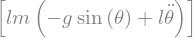

In [27]:
# Equations of Motion
LE = LagrangesMethod(L, [theta])
eom_rel = LE.form_lagranges_equations()

print("Position Vector:")
display(P.pos_from(O).express(N))
print("Velocity Vector:")
display(P.vel(N).express(N))
print("Equation of Motion:")
display(sp.simplify(eom_rel))

# Rigid Body

## Setup

In [28]:
import sympy as sp
from sympy.physics.mechanics import *
import matplotlib.pyplot as plt

init_vprinting()

In [29]:
# Symbols
theta = dynamicsymbols('theta')
t = sp.symbols('t')

# Parameters
m, g, l = sp.symbols('m g l')

## Absolute Coordinates

In [30]:
# Define Frames
N = ReferenceFrame('N')

BodyFrame = N.orientnew('BodyFrame', 'Axis', [theta, N.z])  # <--- NEW
BodyFrame.set_ang_vel(N, theta.diff(t) * N.z)

In [31]:
# Define Geometry
O = Point('O')
G1 = O.locatenew('G1', (l/2)*sp.sin(theta)*N.x - (l/2)*sp.cos(theta)*N.y) # Center of mass of rod
P = O.locatenew('P', l * sp.sin(theta) * N.x - l * sp.cos(theta) * N.y) # Point mass

In [32]:
# Define Velocities
O.set_vel(N, 0) # O has 0 velocity in the reference frame
G1.set_vel(N, G1.pos_from(O).dt(N)) # time derivative

In [33]:
# Define Inertias
I1 = inertia(N, 0, 0, (1/3)*m*l**2)

In [34]:
# Define Rigid Bodies
R1 = RigidBody('R1', G1, BodyFrame, m, (I1, G1)) # inertia of rod about center of mass

In [35]:
# Potential Energy
T = R1.kinetic_energy(N)
V = m * g * G1.pos_from(O).dot(N.y)

L = T - V

Equation of Motion:


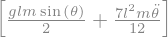

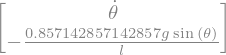

In [36]:
# EOMs
LE = LagrangesMethod(L, [theta])
eom = LE.form_lagranges_equations()

print("Equation of Motion:")
display(sp.nsimplify(sp.simplify(eom).expand()))

display(sp.simplify(LE.rhs()))

## Relative Coordinates

In [37]:
# Define Frames
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta, N.z])
A.set_ang_vel(N, theta.diff() * N.z)

In [38]:
# Define Geometry
O = Point('O')
G = O.locatenew('G', -l/2 * A.y)
P = O.locatenew('P', l * A.y)

In [39]:
# Set Velocities
O.set_vel(N, 0)
G.v2pt_theory(O,N,A);

In [50]:
# Define Inertias
I = inertia(A, 0, 0, m * l**2 / 3)

In [51]:
# Rigid Body
R = RigidBody('R', G, A, m, (I, O))

In [52]:
# Lagrangian
R.potential_energy = m * g * G.pos_from(O).dot(N.y)
L = Lagrangian(N, R)

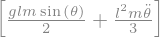

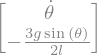

In [53]:
LM = LagrangesMethod(L, [theta])
eom = LM.form_lagranges_equations()

display(eom)

LM.rhs()